In [30]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

# Create *known* parameters
weight = 0.3
bias = 0.9

# Create data
start = 0
end = 1
step = 0.01
X = torch.arange(start, end, step).unsqueeze(dim=1)
Y = weight * X + bias

X[:10], Y[:10]

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400],
         [0.0500],
         [0.0600],
         [0.0700],
         [0.0800],
         [0.0900]]),
 tensor([[0.9000],
         [0.9030],
         [0.9060],
         [0.9090],
         [0.9120],
         [0.9150],
         [0.9180],
         [0.9210],
         [0.9240],
         [0.9270]]))

In [31]:
X_split = int(0.8 * len(X))
X_train, Y_train = X[:X_split], Y[:X_split]
X_test, Y_test = X[X_split:], Y[X_split:]

len(X_train), len(Y_train), len(X_test), len(Y_test)

(80, 80, 20, 20)

In [32]:
def plot_predictions( train_data=X_train,
                      train_labels=Y_train,
                      test_data=X_test,
                      test_labels=Y_test,
                      predictions=None):


  plt.figure(figsize=(10,7))
  plt.scatter(train_data, train_labels, c='b', s=4, label='Training label')
  plt.scatter(test_data, test_labels, c='g', s=4, label='Testing label')

  if predictions is not None:

    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
    plt.legend(prop={"size": 14});

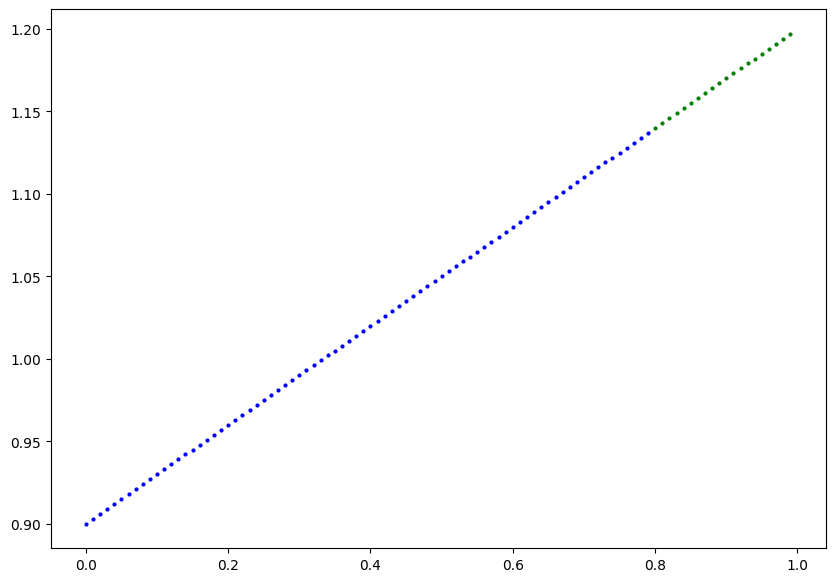

In [33]:
plot_predictions()

In [34]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, dtype = torch.float), requires_grad = True)
    self.bias = nn.Parameter(torch.randn(1, dtype = torch.float), requires_grad = True)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

In [35]:
torch.manual_seed(42)

model_1 = LinearRegressionModel()

model_1.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

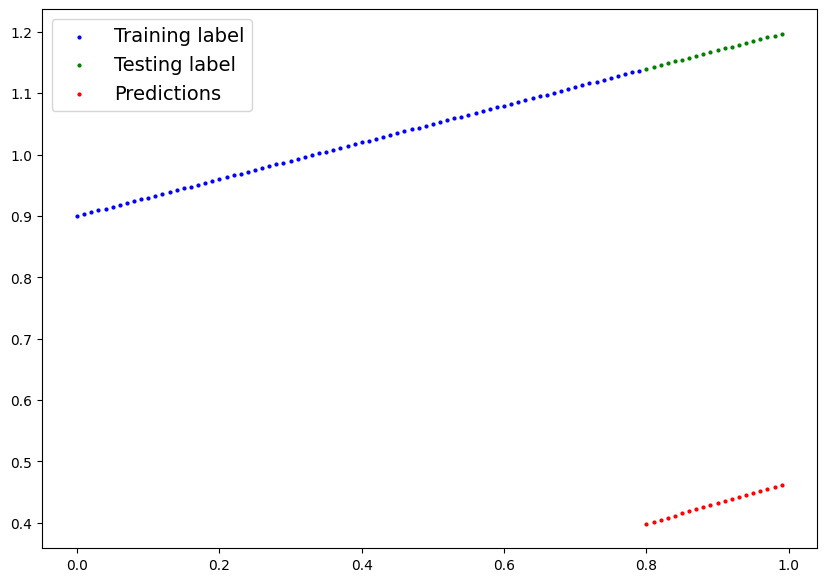

In [36]:
with torch.inference_mode():
  y_preds = model_1(X_test)

  plot_predictions(predictions = y_preds)

In [37]:
#create a loss function
loss_fn = nn.L1Loss()

#set an optimizer
optimizer = torch.optim.SGD(params = model_1.parameters(), lr = 0.01)

In [38]:
torch.manual_seed(42)

epochs = 300

X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)


train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
  model_1.train()

  y_preds = model_1(X_train)

  train_loss = loss_fn(y_preds, Y_train)
  train_loss_values.append(train_loss)

  optimizer.zero_grad()

  train_loss.backward()

  optimizer.step()

  model_1.eval()

  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss = loss_fn(test_pred, Y_test)
    test_loss_values.append(test_loss)

    if epoch % 10 == 0:
      epoch_count.append(epoch)
      train_loss_values.append(train_loss.detach().numpy())
      test_loss_values.append(test_loss.detach().numpy())
      print(f"Epoch: {epoch} | MAE Train Loss: {train_loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.7566978335380554 | MAE Test Loss: 0.7248174548149109 
Epoch: 10 | MAE Train Loss: 0.6410952806472778 | MAE Test Loss: 0.5894648432731628 
Epoch: 20 | MAE Train Loss: 0.5254928469657898 | MAE Test Loss: 0.4541124403476715 
Epoch: 30 | MAE Train Loss: 0.40989047288894653 | MAE Test Loss: 0.31876006722450256 
Epoch: 40 | MAE Train Loss: 0.2942880392074585 | MAE Test Loss: 0.18340764939785004 
Epoch: 50 | MAE Train Loss: 0.17868563532829285 | MAE Test Loss: 0.04805523157119751 
Epoch: 60 | MAE Train Loss: 0.07658576965332031 | MAE Test Loss: 0.07274086028337479 
Epoch: 70 | MAE Train Loss: 0.05743539333343506 | MAE Test Loss: 0.11017072200775146 
Epoch: 80 | MAE Train Loss: 0.05255373567342758 | MAE Test Loss: 0.11581540107727051 
Epoch: 90 | MAE Train Loss: 0.04897591844201088 | MAE Test Loss: 0.11232650279998779 
Epoch: 100 | MAE Train Loss: 0.045542728155851364 | MAE Test Loss: 0.10467890650033951 
Epoch: 110 | MAE Train Loss: 0.0421157106757164 | MAE Test L

In [39]:
model_1.eval()

with torch.inference_mode():
  y_preds = model_1(X_test)
y_preds

tensor([[1.1464],
        [1.1495],
        [1.1525],
        [1.1556],
        [1.1587],
        [1.1617],
        [1.1648],
        [1.1679],
        [1.1709],
        [1.1740],
        [1.1771],
        [1.1801],
        [1.1832],
        [1.1863],
        [1.1893],
        [1.1924],
        [1.1955],
        [1.1985],
        [1.2016],
        [1.2047]])

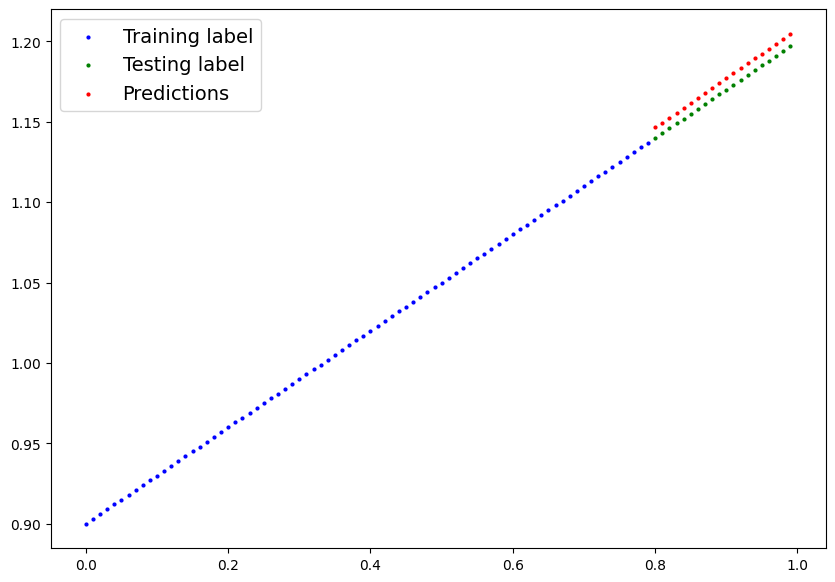

In [40]:
plot_predictions(predictions=y_preds)

In [42]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_1.pth


In [43]:
!ls -l models/01_pytorch_workflow_model_1.pth

-rw-r--r-- 1 root root 1680 May  3 13:33 models/01_pytorch_workflow_model_1.pth


In [45]:
loaded_model_1 = LinearRegressionModel()

loaded_model_1.load_state_dict(torch.load(f='models/01_pytorch_workflow_model_1.pth'))

<All keys matched successfully>

In [46]:
loaded_model_1.eval()

with torch.inference_mode():
    loaded_model_preds = loaded_model_1(X_test)

In [47]:
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])